In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Plot sytles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Base directory for data
DATA_PATH = Path("example_data/arashnic_building-sites-power-consupmtion-dataset")


## 1. Load All Datasets

Quikcly loading all to see what's there.

In [2]:
delimiter = ';'  # Default is ",", but this dataset uses ";"

# Load all datasets
df_train = pd.read_csv(DATA_PATH / "power-laws-forecasting-energy-consumption-training-data.csv", delimiter=delimiter)
df_test = pd.read_csv(DATA_PATH / "power-laws-forecasting-energy-consumption-test-data.csv", delimiter=delimiter)
df_metadata = pd.read_csv(DATA_PATH / "power-laws-forecasting-energy-consumption-metadata.csv", delimiter=delimiter)
df_weather = pd.read_csv(DATA_PATH / "power-laws-forecasting-energy-consumption-weather.csv", delimiter=delimiter)
df_holidays = pd.read_csv(DATA_PATH / "power-laws-forecasting-energy-consumption-holidays.csv", delimiter=delimiter)
df_submission = pd.read_csv(DATA_PATH / "power-laws-forecasting-energy-consumption-submission-forecast-period.csv", delimiter=delimiter)

print(f"\nDataset files:")
print(f"1. Training data: {df_train.shape}")
print(f"2. Test data: {df_test.shape}")
print(f"3. Metadata: {df_metadata.shape}")
print(f"4. Weather: {df_weather.shape}")
print(f"5. Holidays: {df_holidays.shape}")
print(f"6. Submission format: {df_submission.shape}")



Dataset files:
1. Training data: (6559830, 5)
2. Test data: (1309176, 5)
3. Metadata: (267, 11)
4. Weather: (3957035, 4)
5. Holidays: (8387, 3)
6. Submission format: (6974, 2)


## 2. Training Data Exploration

The training data contains historical energy consumption values for each building.


In [3]:
print("Training Data Info:")
print("=" * 80)
print(f"Shape: {df_train.shape}")
print(f"\nColumn Names and Types:")
print(df_train.dtypes)
print(f"\nFirst 5 rows:")
df_train.head()


Training Data Info:
Shape: (6559830, 5)

Column Names and Types:
obs_id          int64
SiteId          int64
Timestamp      object
ForecastId      int64
Value         float64
dtype: object

First 5 rows:


,obs_id,SiteId,Timestamp,ForecastId,Value
0,4852050,42,2016-10-18T02:45:00+00:00,1087,26397.049623
1,1638923,42,2016-10-18T11:45:00+00:00,1087,42958.364641
2,5748910,42,2016-10-18T20:45:00+00:00,1087,27096.919666
3,38199,42,2016-10-20T10:45:00+00:00,1087,50211.408087
4,1338204,42,2016-10-20T18:45:00+00:00,1087,50503.305105


In [4]:
# Check for missing values and basic statistics
print("Missing Values:")
print(df_train.isnull().sum())
print("\n" + "=" * 80)
print("\nBasic Statistics:")
df_train.describe()


Missing Values:
obs_id            0
SiteId            0
Timestamp         0
ForecastId        0
Value         86601
dtype: int64


Basic Statistics:


,obs_id,SiteId,ForecastId,Value
count,6.559830e+06,6.559830e+06,6.559830e+06,6.473229e+06
mean,3.935106e+06,1.620964e+02,3.482184e+03,3.560104e+05
std,2.271511e+06,9.392171e+01,2.009486e+03,3.309454e+08
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.968046e+06,8.700000e+01,1.744000e+03,3.492465e+03
50%,3.935262e+06,1.730000e+02,3.489000e+03,1.408683e+04
75%,5.901983e+06,2.370000e+02,5.216000e+03,4.649371e+04
max,7.869005e+06,3.050000e+02,6.974000e+03,6.404683e+11


In [5]:
# Analyze unique values and temporal coverage
print("Unique Values:")
print(f"Number of unique SiteIds: {df_train['SiteId'].nunique()}")
print(f"Number of unique ForecastIds: {df_train['ForecastId'].nunique()}")
print(f"Total observations: {len(df_train)}")

# Convert Timestamp to datetime
df_train['Timestamp'] = pd.to_datetime(df_train['Timestamp'])

print(f"\nTime Range:")
print(f"Start: {df_train['Timestamp'].min()}")
print(f"End: {df_train['Timestamp'].max()}")
print(f"Duration: {df_train['Timestamp'].max() - df_train['Timestamp'].min()}")


Unique Values:
Number of unique SiteIds: 267
Number of unique ForecastIds: 6974
Total observations: 6559830

Time Range:
Start: 2009-06-23 06:45:00+00:00
End: 2017-12-08 15:30:00+00:00
Duration: 3090 days 08:45:00


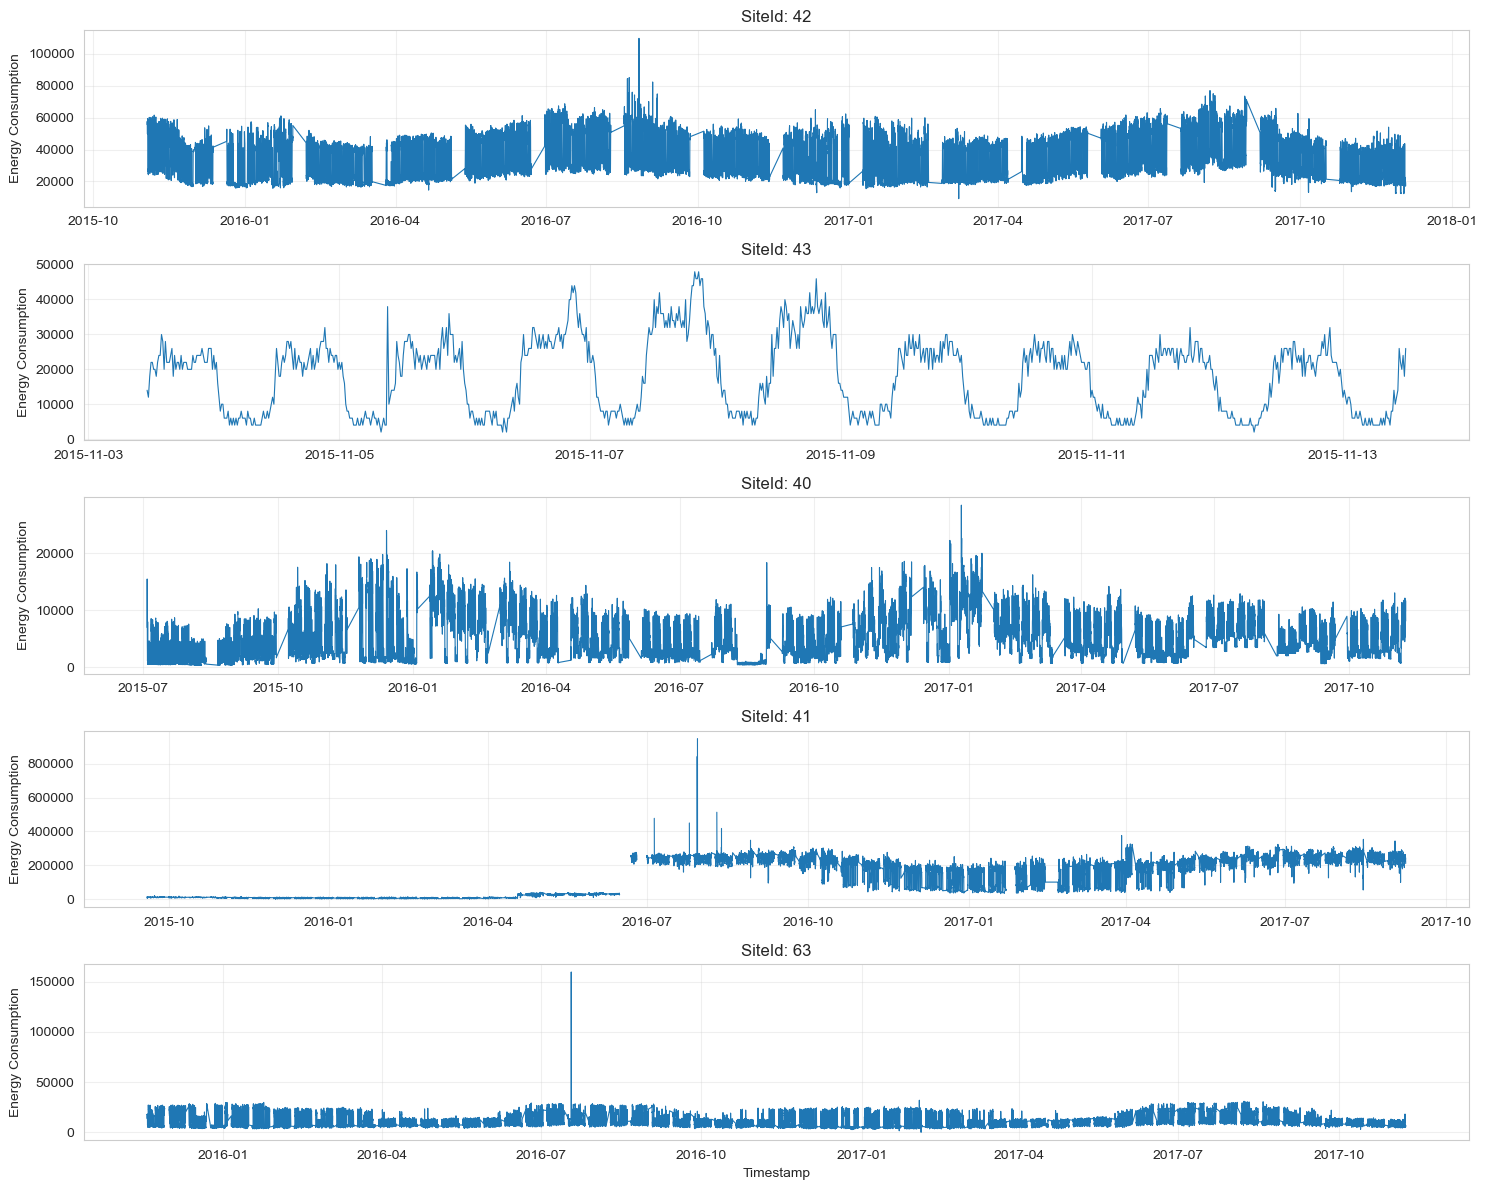

In [6]:
# Sample time series for a few buildings
sample_sites = df_train['SiteId'].unique()[:5]

fig, axes = plt.subplots(5, 1, figsize=(15, 12))

for idx, site_id in enumerate(sample_sites):
    site_data = df_train[df_train['SiteId'] == site_id].sort_values('Timestamp')
    axes[idx].plot(site_data['Timestamp'], site_data['Value'], linewidth=0.8)
    axes[idx].set_title(f'SiteId: {site_id}')
    axes[idx].set_ylabel('Energy Consumption')
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()


## 3. Building Metadata Exploration

The metadata contains information about each building including surface area, sampling rate, base temperature, and work day information.


In [7]:
# Examine metadata structure
print("Metadata Info:")
print("=" * 80)
print(f"Shape: {df_metadata.shape}")
print(f"\nColumn Names and Types:")
print(df_metadata.dtypes)
print(f"\nFirst 10 rows:")
df_metadata.head(10)


Metadata Info:
Shape: (267, 11)

Column Names and Types:
SiteId                 int64
Surface              float64
Sampling             float64
BaseTemperature      float64
MondayIsDayOff          bool
TuesdayIsDayOff         bool
WednesdayIsDayOff       bool
ThursdayIsDayOff        bool
FridayIsDayOff          bool
SaturdayIsDayOff        bool
SundayIsDayOff          bool
dtype: object

First 10 rows:


,SiteId,Surface,Sampling,BaseTemperature,MondayIsDayOff,TuesdayIsDayOff,WednesdayIsDayOff,ThursdayIsDayOff,FridayIsDayOff,SaturdayIsDayOff,SundayIsDayOff
0,207,7964.873347,30.0,18.0,False,False,False,False,False,True,True
1,7,15168.125971,30.0,18.0,False,False,False,False,False,True,True
2,74,424.340663,15.0,18.0,False,False,False,False,False,True,True
3,239,1164.822636,15.0,18.0,False,False,False,False,False,True,True
4,274,1468.246690,5.0,18.0,False,False,False,False,False,True,True
5,164,6176.042092,15.0,18.0,False,False,False,False,False,True,True
6,236,9427.610546,15.0,18.0,False,False,False,False,False,True,True
7,100,9047.136190,15.0,18.0,False,False,False,False,False,True,True
8,101,9024.155117,15.0,18.0,False,False,False,False,False,True,True
9,249,4879.621806,15.0,18.0,False,False,False,False,False,True,True


In [8]:
# Check for missing values and statistics
print("Missing Values in Metadata:")
print(df_metadata.isnull().sum())
print("\n" + "=" * 80)
print("\nBasic Statistics:")
df_metadata.describe()
print("\n" + "=" * 80)
print(f"\nUnique Sites in Metadata: {df_metadata['SiteId'].nunique()}")
print(f"Sampling rates available: {sorted(df_metadata['Sampling'].unique())}")


Missing Values in Metadata:
SiteId               0
Surface              0
Sampling             0
BaseTemperature      0
MondayIsDayOff       0
TuesdayIsDayOff      0
WednesdayIsDayOff    0
ThursdayIsDayOff     0
FridayIsDayOff       0
SaturdayIsDayOff     0
SundayIsDayOff       0
dtype: int64


Basic Statistics:


Unique Sites in Metadata: 267
Sampling rates available: [np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(30.0)]


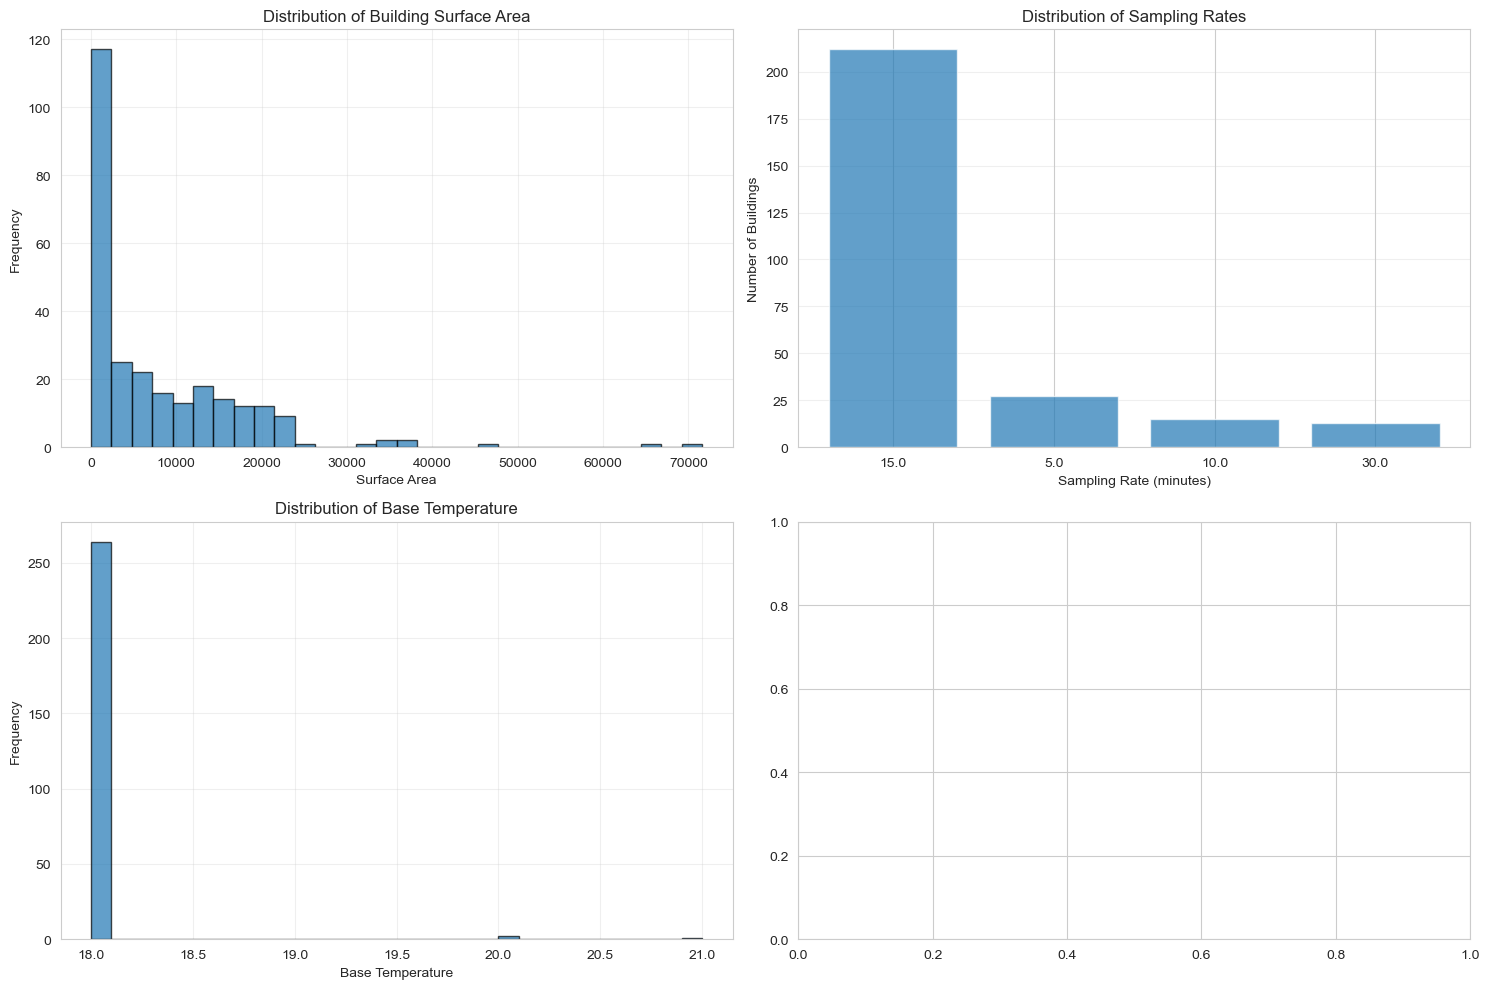

In [9]:
# Visualize metadata features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Surface area distribution
axes[0, 0].hist(df_metadata['Surface'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Surface Area')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Building Surface Area')
axes[0, 0].grid(alpha=0.3)

# Sampling rate distribution
sampling_counts = df_metadata['Sampling'].value_counts()
axes[0, 1].bar(sampling_counts.index.astype(str), sampling_counts.values, alpha=0.7)
axes[0, 1].set_xlabel('Sampling Rate (minutes)')
axes[0, 1].set_ylabel('Number of Buildings')
axes[0, 1].set_title('Distribution of Sampling Rates')
axes[0, 1].grid(alpha=0.3, axis='y')

# Base temperature distribution
axes[1, 0].hist(df_metadata['BaseTemperature'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Base Temperature')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Base Temperature')
axes[1, 0].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Weather Data Exploration

Weather data from multiple stations within 30km of each building site.


In [10]:
# Examine weather data structure
print("Weather Data Info:")
print("=" * 80)
print(f"Shape: {df_weather.shape}")
print(f"\nColumn Names and Types:")
print(df_weather.dtypes)
print(f"\nFirst 10 rows:")
df_weather.head(10)


Weather Data Info:
Shape: (3957035, 4)

Column Names and Types:
Timestamp       object
Temperature    float64
Distance       float64
SiteId           int64
dtype: object

First 10 rows:


,Timestamp,Temperature,Distance,SiteId
0,2017-03-03T19:00:00+00:00,10.6,27.489346,51
1,2017-03-03T19:20:00+00:00,11.0,28.663082,51
2,2017-03-03T20:00:00+00:00,6.3,28.307039,51
3,2017-03-03T21:55:00+00:00,10.0,29.797449,51
4,2017-03-03T23:00:00+00:00,5.4,28.307039,51
5,2017-03-04T01:00:00+00:00,5.4,28.307039,51
6,2017-03-04T03:00:00+00:00,7.6,29.797449,51
7,2017-03-04T04:50:00+00:00,8.0,28.663082,51
8,2017-03-04T05:55:00+00:00,8.0,29.797449,51
9,2017-03-04T07:00:00+00:00,7.9,28.663082,51


In [11]:
# Check missing values and statistics
print("Missing Values in Weather Data:")
print(df_weather.isnull().sum())
print("\n" + "=" * 80)
print("\nBasic Statistics:")
print(df_weather.describe())
print("\n" + "=" * 80)

# Convert Timestamp
df_weather['Timestamp'] = pd.to_datetime(df_weather['Timestamp'])

print(f"\nSites with weather data: {df_weather['SiteId'].nunique()}")
print(f"Time range: {df_weather['Timestamp'].min()} to {df_weather['Timestamp'].max()}")
print(f"\nDistance from weather stations (km):")
print(f"  Min: {df_weather['Distance'].min():.2f}")
print(f"  Max: {df_weather['Distance'].max():.2f}")
print(f"  Mean: {df_weather['Distance'].mean():.2f}")


Missing Values in Weather Data:
Timestamp      0
Temperature    0
Distance       0
SiteId         0
dtype: int64


Basic Statistics:
        Temperature      Distance        SiteId
count  3.957035e+06  3.957035e+06  3.957035e+06
mean   1.435104e+01  1.634896e+01  2.915222e+01
std    7.620629e+00  8.513661e+00  1.494767e+01
min   -1.700000e+01  1.298667e+00  2.000000e+00
25%    9.000000e+00  7.648476e+00  2.100000e+01
50%    1.400000e+01  1.637783e+01  3.000000e+01
75%    1.910000e+01  2.399885e+01  4.000000e+01
max    4.500000e+01  2.997784e+01  5.700000e+01


Sites with weather data: 49
Time range: 2013-01-01 13:00:00+00:00 to 2017-12-31 10:30:00+00:00

Distance from weather stations (km):
  Min: 1.30
  Max: 29.98
  Mean: 16.35


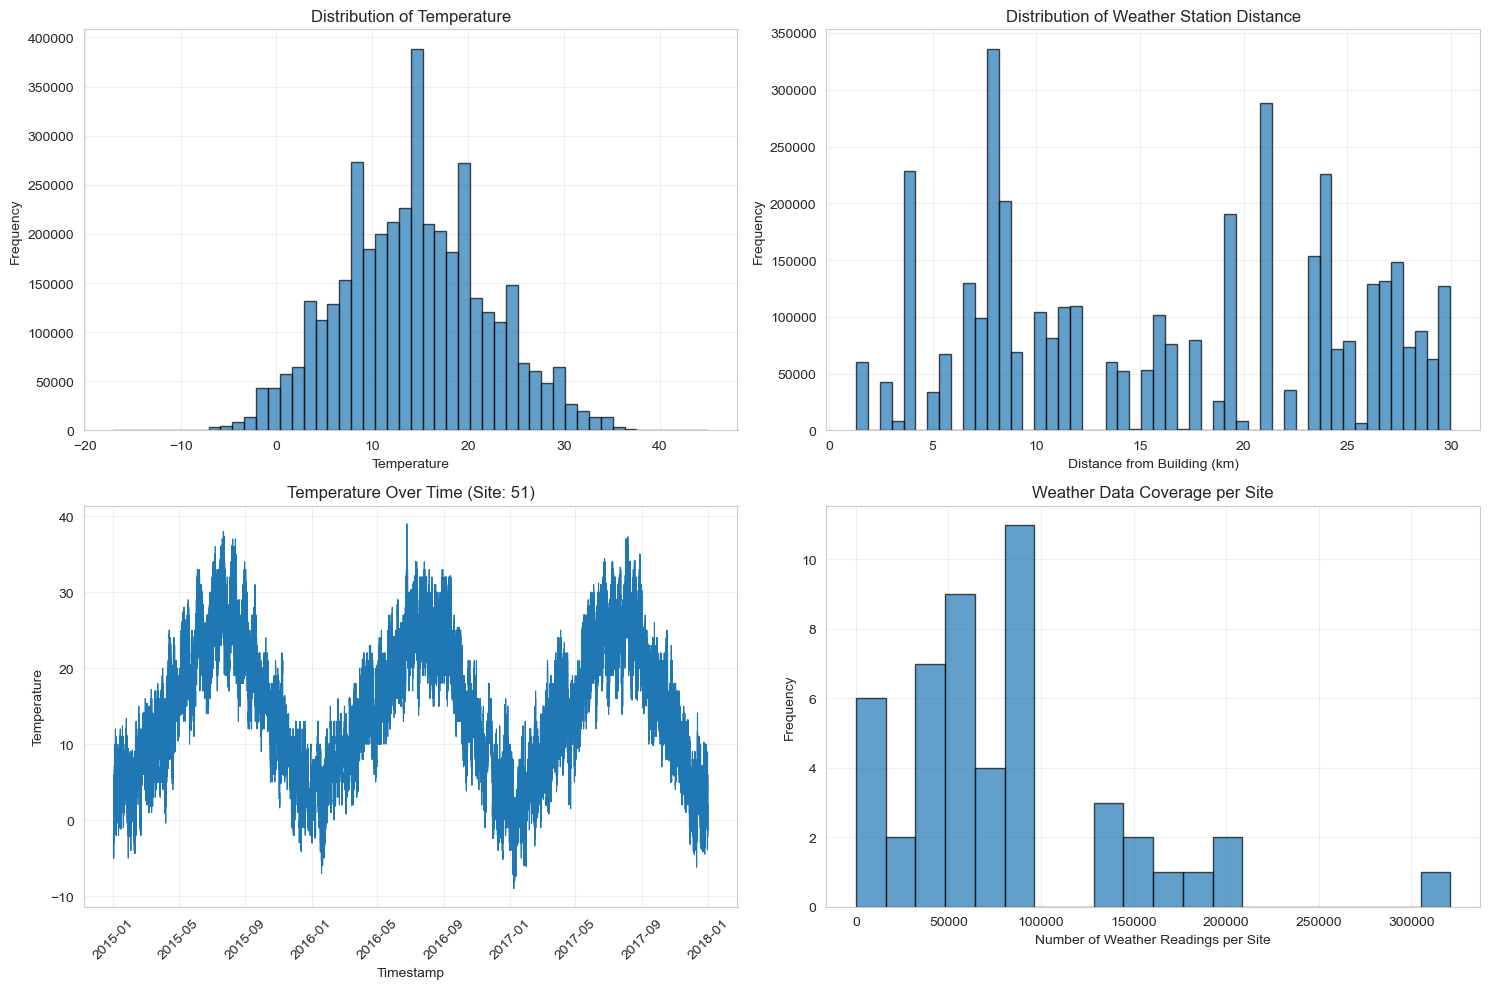

In [12]:
# Visualize weather data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperature distribution
axes[0, 0].hist(df_weather['Temperature'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Temperature')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Temperature')
axes[0, 0].grid(alpha=0.3)

# Distance distribution
axes[0, 1].hist(df_weather['Distance'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Distance from Building (km)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Weather Station Distance')
axes[0, 1].grid(alpha=0.3)

# Temperature over time (sample)
sample_site_weather = df_weather[df_weather['SiteId'] == df_weather['SiteId'].unique()[0]].sort_values('Timestamp')
axes[1, 0].plot(sample_site_weather['Timestamp'], sample_site_weather['Temperature'], linewidth=0.8)
axes[1, 0].set_xlabel('Timestamp')
axes[1, 0].set_ylabel('Temperature')
axes[1, 0].set_title(f'Temperature Over Time (Site: {df_weather["SiteId"].unique()[0]})')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Number of weather stations per site
stations_per_site = df_weather.groupby('SiteId')['Distance'].count()
axes[1, 1].hist(stations_per_site, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Weather Readings per Site')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Weather Data Coverage per Site')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Holiday Data Exploration

Public holidays that may affect energy consumption patterns.


In [13]:
# Examine holiday data structure
print("Holiday Data Info:")
print("=" * 80)
print(f"Shape: {df_holidays.shape}")
print(f"\nColumn Names and Types:")
print(df_holidays.dtypes)
print(f"\nFirst 15 rows:")
df_holidays.head(15)


Holiday Data Info:
Shape: (8387, 3)

Column Names and Types:
Date       object
Holiday    object
SiteId      int64
dtype: object

First 15 rows:


,Date,Holiday,SiteId
0,2016-02-15,Washington's Birthday,1
1,2017-05-29,Memorial Day,1
2,2017-11-23,Thanksgiving Day,1
3,2017-12-29,New Years Eve Shift,1
4,2017-12-31,New Years Eve,1
5,2014-01-01,New year,1
6,2015-01-19,"Birthday of Martin Luther King, Jr.",1
7,2017-01-02,New year (Observed),12
8,2017-11-10,Veterans Day (Observed),12
9,2017-01-01,New year,13


In [14]:
# Analyze holiday data
print("Missing Values in Holiday Data:")
print(df_holidays.isnull().sum())
print("\n" + "=" * 80)

df_holidays['Date'] = pd.to_datetime(df_holidays['Date'])

print(f"\nSites with holiday data: {df_holidays['SiteId'].nunique()}")
print(f"Total unique holidays: {df_holidays['Holiday'].nunique()}")
print(f"Date range: {df_holidays['Date'].min()} to {df_holidays['Date'].max()}")
print(f"\nMost common holidays:")
print(df_holidays['Holiday'].value_counts().head(10))


Missing Values in Holiday Data:
Date       0
Holiday    0
SiteId     0
dtype: int64


Sites with holiday data: 227
Total unique holidays: 110
Date range: 2009-01-01 00:00:00 to 2018-01-01 00:00:00

Most common holidays:
Holiday
New year                        707
Christmas Day                   707
Easter Monday                   652
All Saints Day                  523
Assumption of Mary to Heaven    521
Epiphany                        481
Immaculate Conception           473
Liberation Day                  467
St Stephen's Day                462
Republic Day                    462
Name: count, dtype: int64


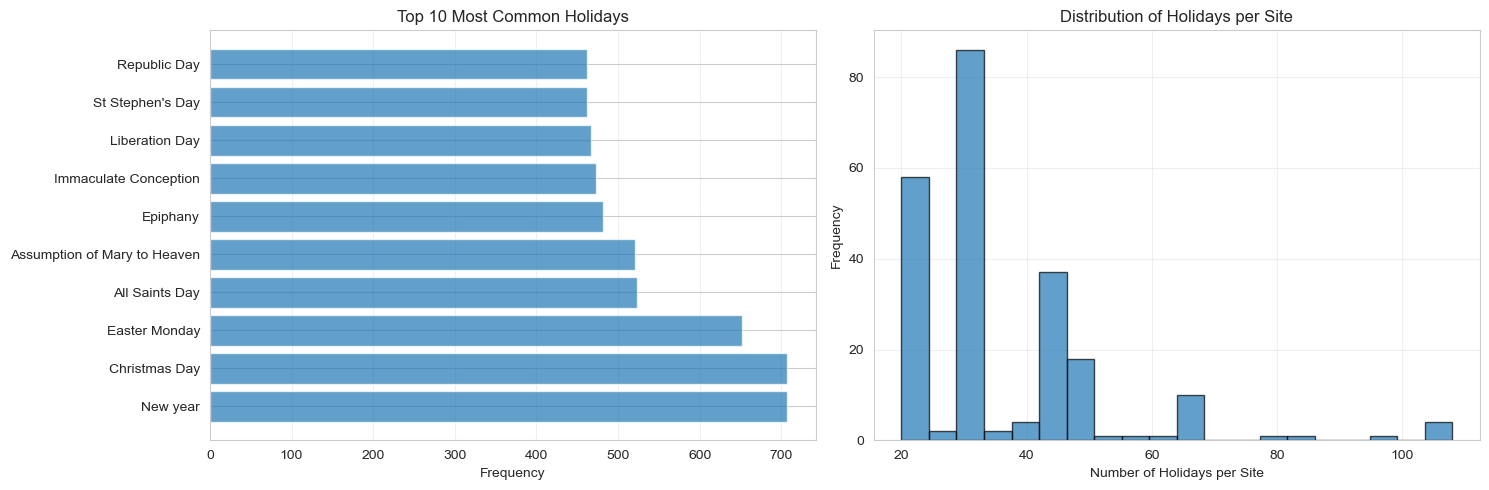

In [15]:
# Visualize holiday data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top holidays
top_holidays = df_holidays['Holiday'].value_counts().head(10)
axes[0].barh(range(len(top_holidays)), top_holidays.values, alpha=0.7)
axes[0].set_yticks(range(len(top_holidays)))
axes[0].set_yticklabels(top_holidays.index)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 10 Most Common Holidays')
axes[0].grid(alpha=0.3, axis='x')

# Holidays per site
holidays_per_site = df_holidays.groupby('SiteId').size()
axes[1].hist(holidays_per_site, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Holidays per Site')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Holidays per Site')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Test Data & Submission Format

Understanding the test data structure and what forecasts are required.


In [16]:
# Examine test data structure
print("Test Data Info:")
print("=" * 80)
print(f"Shape: {df_test.shape}")
print(f"\nColumn Names and Types:")
print(df_test.dtypes)
print(f"\nFirst 10 rows:")
df_test.head(10)


Test Data Info:
Shape: (1309176, 5)

Column Names and Types:
obs_id          int64
SiteId          int64
Timestamp      object
ForecastId      int64
Value         float64
dtype: object

First 10 rows:


,obs_id,SiteId,Timestamp,ForecastId,Value
0,323604,235,2014-01-02T19:00:00+00:00,5004,157265.446409
1,2813181,235,2014-01-02T22:00:00+00:00,5004,155498.418922
2,4006999,235,2014-01-02T22:45:00+00:00,5004,155498.418922
3,106973,235,2014-01-03T00:30:00+00:00,5004,157265.446409
4,6793052,235,2014-01-13T14:15:00+00:00,5005,91885.429363
5,2529014,235,2014-01-13T23:15:00+00:00,5005,155498.418922
6,418377,235,2014-01-14T00:00:00+00:00,5005,155498.418922
7,1470287,235,2014-01-14T02:00:00+00:00,5005,155498.418922
8,184973,235,2014-01-14T14:15:00+00:00,5005,38874.604730
9,4039942,235,2014-01-14T19:45:00+00:00,5005,67147.044534


In [17]:
# Examine submission format
print("Submission Format Info:")
print("=" * 80)
print(f"Shape: {df_submission.shape}")
print(f"\nColumn Names and Types:")
print(df_submission.dtypes)
print(f"\nFirst 10 rows:")
df_submission.head(10)


Submission Format Info:
Shape: (6974, 2)

Column Names and Types:
ForecastId          int64
ForecastPeriodNS    int64
dtype: object

First 10 rows:


,ForecastId,ForecastPeriodNS
0,123,900000000000
1,264,900000000000
2,596,900000000000
3,914,900000000000
4,1053,900000000000
5,1504,900000000000
6,1591,900000000000
7,1916,900000000000
8,1989,3600000000000
9,2363,3600000000000


In [18]:
# Analyze submission requirements
print("Submission Analysis:")
print("=" * 80)
print(f"Total predictions required: {len(df_submission)}")
print(f"Unique ForecastIds: {df_submission['ForecastId'].nunique()}")

print(f"\nSubmission file columns: {list(df_submission.columns)}")


Submission Analysis:
Total predictions required: 6974
Unique ForecastIds: 6974

Submission file columns: ['ForecastId', 'ForecastPeriodNS']


## 7. Data Coverage & Relationships

Analyzing how the different datasets relate to each other and what coverage we have.


In [19]:
# Analyze data coverage across datasets
sites_train = set(df_train['SiteId'].unique())
sites_metadata = set(df_metadata['SiteId'].unique())
sites_weather = set(df_weather['SiteId'].unique())
sites_holiday = set(df_holidays['SiteId'].unique())

print("Data Coverage Analysis:")
print("=" * 80)
print(f"Sites in training data: {len(sites_train)}")
print(f"Sites in metadata: {len(sites_metadata)}")
print(f"Sites with weather data: {len(sites_weather)}")
print(f"Sites with holiday data: {len(sites_holiday)}")

print(f"\nOverlap Analysis:")
print(f"Sites with all data (train+metadata+weather+holiday): {len(sites_train & sites_metadata & sites_weather & sites_holiday)}")
print(f"Sites with train+metadata+weather: {len(sites_train & sites_metadata & sites_weather)}")
print(f"Sites with train+metadata: {len(sites_train & sites_metadata)}")

print(f"\nSites missing data:")
print(f"Training sites without weather: {len(sites_train - sites_weather)}")
print(f"Training sites without holiday: {len(sites_train - sites_holiday)}")
print(f"Training sites without metadata: {len(sites_train - sites_metadata)}")


Data Coverage Analysis:
Sites in training data: 267
Sites in metadata: 267
Sites with weather data: 49
Sites with holiday data: 227

Overlap Analysis:
Sites with all data (train+metadata+weather+holiday): 29
Sites with train+metadata+weather: 40
Sites with train+metadata: 267

Sites missing data:
Training sites without weather: 227
Training sites without holiday: 40
Training sites without metadata: 0


In [20]:
# Analyze ForecastId relationships
forecasts_train = set(df_train['ForecastId'].unique())
forecasts_submission = set(df_submission['ForecastId'].unique())

print("ForecastId Analysis:")
print("=" * 80)
print(f"Unique ForecastIds in training: {len(forecasts_train)}")
print(f"Unique ForecastIds in submission: {len(forecasts_submission)}")

print(f"\nOverlap:")
print(f"ForecastIds in both train and submission: {len(forecasts_train & forecasts_submission)}")
print(f"ForecastIds only in training: {len(forecasts_train - forecasts_submission)}")
print(f"ForecastIds only in submission: {len(forecasts_submission - forecasts_train)}")

print("\n" + "=" * 80)
print("\nNote: Metadata is organized by SiteId, not ForecastId.")
print("Each SiteId can have multiple ForecastIds (different forecast series).")
print(f"In training data: {len(df_train.groupby('SiteId')['ForecastId'].nunique())} sites")
print(f"Average ForecastIds per site: {df_train.groupby('SiteId')['ForecastId'].nunique().mean():.2f}")


ForecastId Analysis:
Unique ForecastIds in training: 6974
Unique ForecastIds in submission: 6974

Overlap:
ForecastIds in both train and submission: 6974
ForecastIds only in training: 0
ForecastIds only in submission: 0


Note: Metadata is organized by SiteId, not ForecastId.
Each SiteId can have multiple ForecastIds (different forecast series).
In training data: 267 sites
Average ForecastIds per site: 26.12


## 8. Time Granularity Analysis

Understanding the different sampling rates and what they mean for forecasting.


In [24]:
# Analyze sampling rates from metadata
print("Sampling Rate Analysis:")
print("=" * 80)

sampling_summary = df_metadata.groupby('Sampling').agg({
    'SiteId': 'count'
})

print(sampling_summary.sort_index())

print("\n" + "=" * 80)
print("\nInterpretation:")
print("  15 min sampling = Quarterly forecasts (96 per day)")
print("  60 min sampling = Hourly forecasts (24 per day)")
print("  1440 min sampling = Daily forecasts (1 per day)")


Sampling Rate Analysis:
          SiteId
Sampling        
5.0           27
10.0          15
15.0         212
30.0          13


Interpretation:
  15 min sampling = Quarterly forecasts (96 per day)
  60 min sampling = Hourly forecasts (24 per day)
  1440 min sampling = Daily forecasts (1 per day)


## 9. Deep Dive: Single Building Example

Let's examine all available data for a single building to understand the complete picture.


In [25]:
# Select a site that has all types of data
sites_with_all = sites_train & sites_metadata & sites_weather & sites_holiday
if len(sites_with_all) > 0:
    example_site = list(sites_with_all)[0]
else:
    example_site = list(sites_train)[0]

print(f"Deep Dive for SiteId: {example_site}")
print("=" * 80)

# Training data for this site
site_train = df_train[df_train['SiteId'] == example_site]
print(f"\n1. Training Data:")
print(f"   Records: {len(site_train)}")
print(f"   ForecastIds: {site_train['ForecastId'].nunique()}")
print(f"   Time range: {site_train['Timestamp'].min()} to {site_train['Timestamp'].max()}")
print(f"   Value range: [{site_train['Value'].min():.2f}, {site_train['Value'].max():.2f}]")

# Metadata for this site
site_meta = df_metadata[df_metadata['SiteId'] == example_site]
print(f"\n2. Metadata:")
if len(site_meta) > 0:
    print(f"   Surface area: {site_meta['Surface'].values[0] if 'Surface' in site_meta.columns else 'N/A'}")
    print(f"   Sampling rate: {site_meta['Sampling'].values[0] if 'Sampling' in site_meta.columns else 'N/A'} minutes")
    print(f"   Base temperature: {site_meta['BaseTemperature'].values[0] if 'BaseTemperature' in site_meta.columns else 'N/A'}")
else:
    print("   No metadata available")

# Weather data for this site
site_weather = df_weather[df_weather['SiteId'] == example_site]
print(f"\n3. Weather Data:")
if len(site_weather) > 0:
    print(f"   Records: {len(site_weather)}")
    print(f"   Temperature range: [{site_weather['Temperature'].min():.2f}, {site_weather['Temperature'].max():.2f}]")
    print(f"   Station distances: {site_weather['Distance'].unique()}")
else:
    print("   No weather data available")

# Holiday data for this site
site_holidays = df_holidays[df_holidays['SiteId'] == example_site]
print(f"\n4. Holiday Data:")
if len(site_holidays) > 0:
    print(f"   Holidays: {len(site_holidays)}")
    print(f"   Examples: {list(site_holidays['Holiday'].head(5))}")
else:
    print("   No holiday data available")


Deep Dive for SiteId: 12

1. Training Data:
   Records: 450
   ForecastIds: 2
   Time range: 2016-06-09 00:00:00+00:00 to 2017-10-31 00:00:00+00:00
   Value range: [4017461.06, 13236283.82]

2. Metadata:
   Surface area: 33676.246551396136
   Sampling rate: 15.0 minutes
   Base temperature: 18.0

3. Weather Data:
   Records: 21988
   Temperature range: [2.00, 40.00]
   Station distances: [11.28840029 29.94929505 14.65772379  6.12245049  8.48451443 20.38056005]

4. Holiday Data:
   Holidays: 25
   Examples: ['New year (Observed)', 'Veterans Day (Observed)', 'Labor Day', 'Birthday of Martin Luther King, Jr.', 'Cesar Chavez Day']


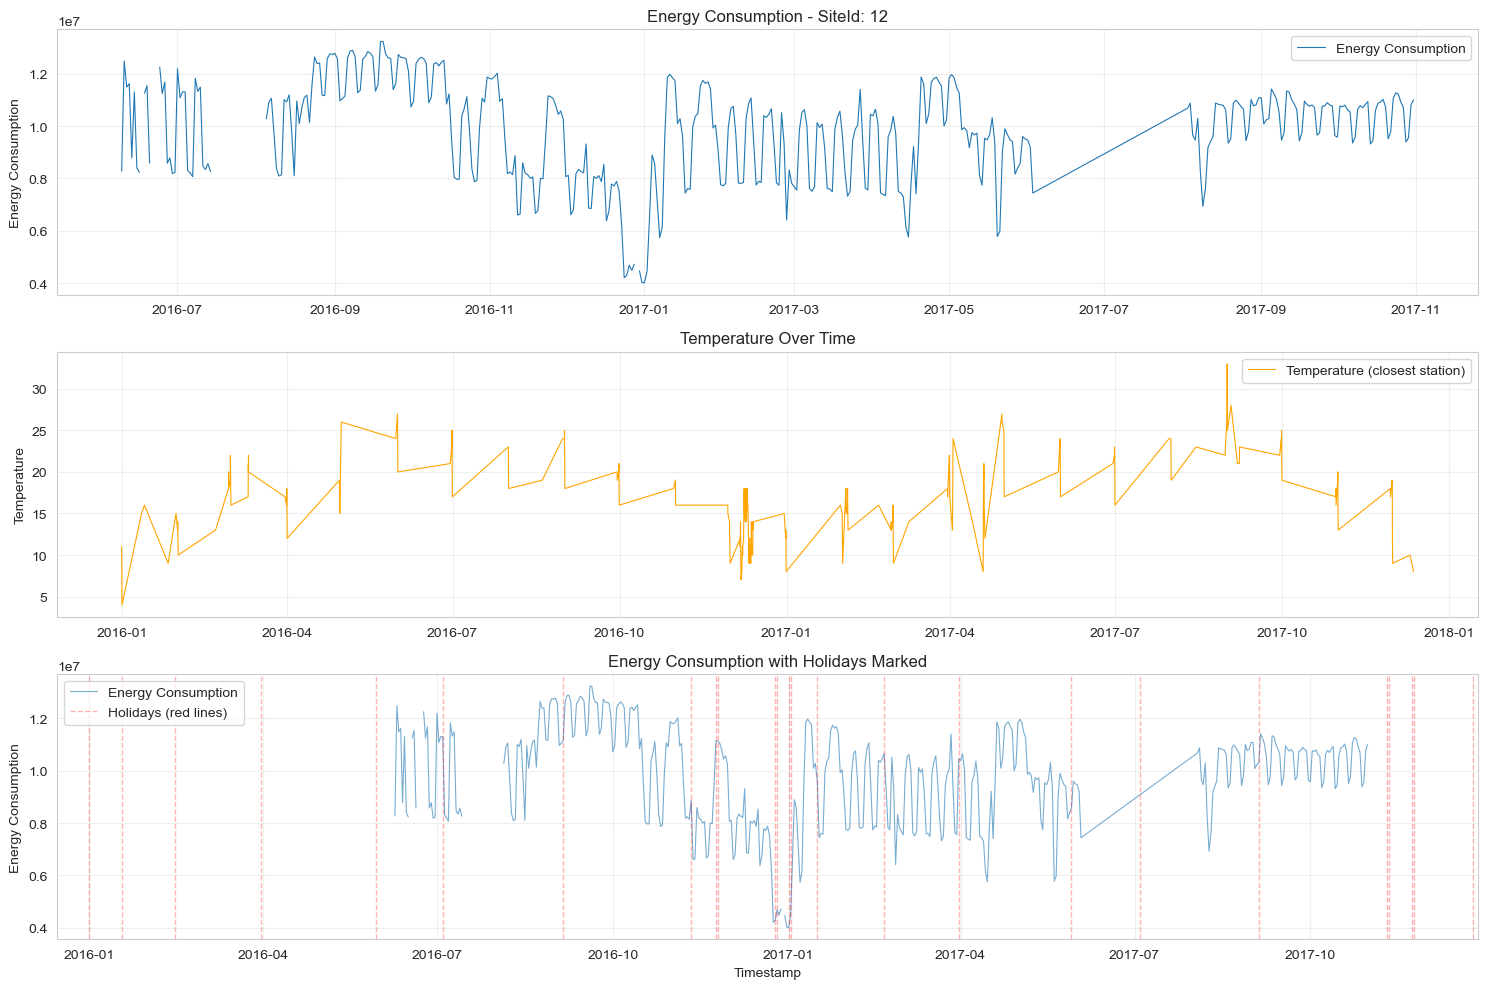

In [26]:
# Visualize the example site
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot energy consumption
site_train_sorted = site_train.sort_values('Timestamp')
axes[0].plot(site_train_sorted['Timestamp'], site_train_sorted['Value'], linewidth=0.8, label='Energy Consumption')
axes[0].set_ylabel('Energy Consumption')
axes[0].set_title(f'Energy Consumption - SiteId: {example_site}')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot temperature if available
if len(site_weather) > 0:
    site_weather_sorted = site_weather.sort_values('Timestamp')
    # If multiple stations, plot the closest one
    if len(site_weather_sorted['Distance'].unique()) > 1:
        closest_distance = site_weather_sorted['Distance'].min()
        site_weather_sorted = site_weather_sorted[site_weather_sorted['Distance'] == closest_distance]
    axes[1].plot(site_weather_sorted['Timestamp'], site_weather_sorted['Temperature'], 
                 linewidth=0.8, color='orange', label=f'Temperature (closest station)')
    axes[1].set_ylabel('Temperature')
    axes[1].set_title('Temperature Over Time')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No weather data available', ha='center', va='center', fontsize=12)
    axes[1].axis('off')

# Mark holidays
axes[2].plot(site_train_sorted['Timestamp'], site_train_sorted['Value'], linewidth=0.8, alpha=0.6, label='Energy Consumption')
if len(site_holidays) > 0:
    for holiday_date in site_holidays['Date']:
        axes[2].axvline(x=holiday_date, color='red', alpha=0.3, linestyle='--', linewidth=1)
    axes[2].legend(['Energy Consumption', 'Holidays (red lines)'])
axes[2].set_xlabel('Timestamp')
axes[2].set_ylabel('Energy Consumption')
axes[2].set_title('Energy Consumption with Holidays Marked')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
